In [1]:
!pip install ultralytics -q

import os, cv2, numpy as np, torch
from PIL import Image as PILImage
from ultralytics import YOLO
from IPython.display import Image, display
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
uploaded_ref = files.upload()
real_ref_path = list(uploaded_ref.keys())[0]

uploaded_query = files.upload()
real_query_path = list(uploaded_query.keys())[0]

Saving IMG_5630 (1).jpeg to IMG_5630 (1).jpeg


Saving IMG_5632.jpeg to IMG_5632.jpeg


Good feature matches: 812
Inlier matches: 448 / 812


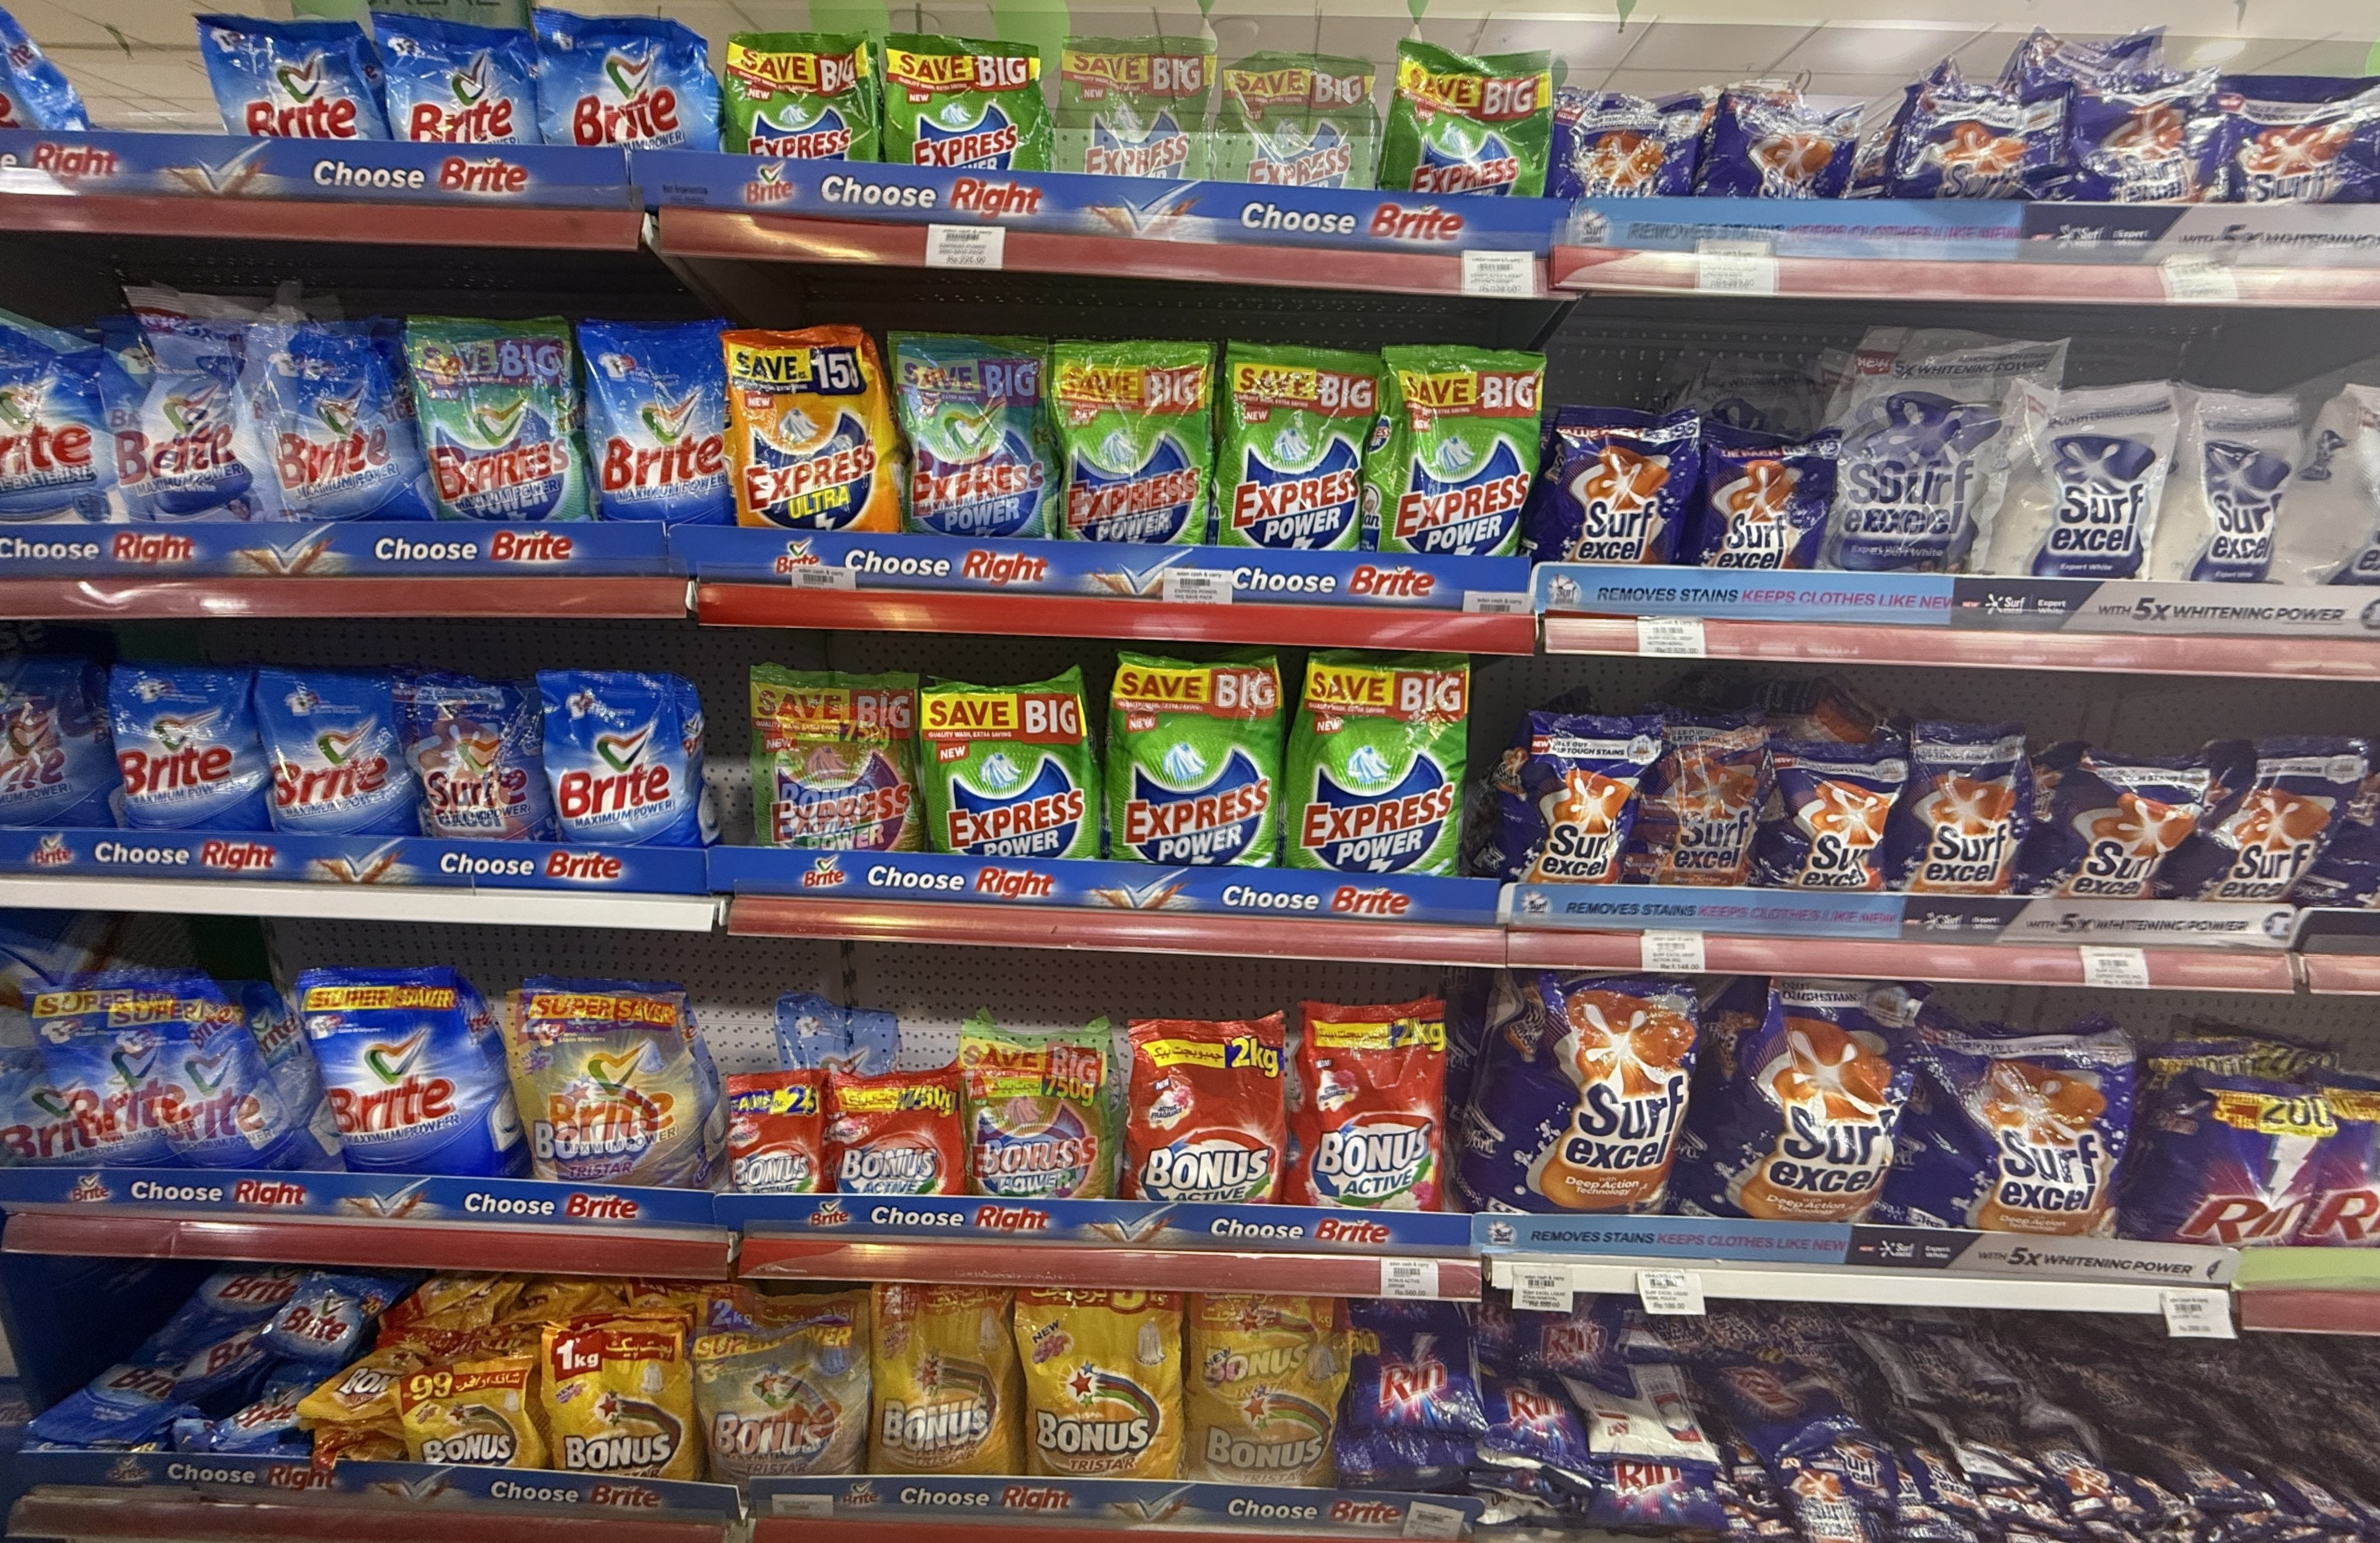

In [3]:
def align_images(ref_path, query_path, out_path="query_aligned.jpg"):
    ref = cv2.imread(ref_path)
    qry = cv2.imread(query_path)
    ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    qry_gray = cv2.cvtColor(qry, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(ref_gray, None)
    kp2, des2 = orb.detectAndCompute(qry_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    print(f"Good feature matches: {len(good)}")

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    print(f"Inlier matches: {int(mask.sum())} / {len(good)}")

    h, w = ref.shape[:2]
    aligned_query = cv2.warpPerspective(qry, np.linalg.inv(H), (w, h))
    cv2.imwrite(out_path, aligned_query)
    return out_path

query_aligned_path = align_images(real_ref_path, real_query_path)

# sanity check — blend the two to eyeball the alignment
ref_img = cv2.imread(real_ref_path)
aligned_img = cv2.imread(query_aligned_path)
blend = cv2.addWeighted(ref_img, 0.5, aligned_img, 0.5, 0)
cv2.imwrite("alignment_check.jpg", blend)
display(Image(filename="alignment_check.jpg"))

In [4]:
DETECT_CLASSES = ["bag", "package", "product"]
DETECT_CONF = 0.05

model = YOLO("yolov8s-world.pt")
model.set_classes(DETECT_CLASSES)

results = model(real_ref_path, conf=DETECT_CONF)
ref_boxes = [box.xyxy[0].tolist() for box in results[0].boxes]
print("Reference detections:", len(ref_boxes))

requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 37 packages in 780ms
Prepared 2 packages in 2.50s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@68dce32140994dfcb645a1320c4ebdc034fc19fd)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 71.0MiB/s]



image 1/1 /content/IMG_5630 (1).jpeg: 416x640 36 packages, 16.5ms
Speed: 59.1ms preprocess, 16.5ms inference, 4.6ms postprocess per image at shape (1, 3, 416, 640)
Reference detections: 36


In [5]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
embed_model = resnet18(weights=weights)
embed_model.fc = torch.nn.Identity()
embed_model.eval().to(device)
transform = weights.transforms()

def get_embedding(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(crop_rgb)
    tensor = transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = embed_model(tensor)
    return emb.squeeze().cpu().numpy()

def is_region_empty(crop, std_threshold=15):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    return gray.std() < std_threshold

def compare_shelves_v3(ref_img_path, query_img_path, ref_boxes, std_threshold=15, sim_threshold=0.85):
    ref_img = cv2.imread(ref_img_path)
    query_img = cv2.imread(query_img_path)
    report = {"missing": [], "misplaced": [], "compliant": []}

    for rbox in ref_boxes:
        x1, y1, x2, y2 = map(int, rbox)
        ref_crop = ref_img[y1:y2, x1:x2]
        query_crop = query_img[y1:y2, x1:x2]
        if ref_crop.size == 0 or query_crop.size == 0:
            continue
        if is_region_empty(query_crop, std_threshold):
            report["missing"].append(rbox)
            continue
        emb_ref, emb_query = get_embedding(ref_crop), get_embedding(query_crop)
        sim = np.dot(emb_ref, emb_query) / (np.linalg.norm(emb_ref) * np.linalg.norm(emb_query) + 1e-6)
        (report["misplaced"] if sim < sim_threshold else report["compliant"]).append(rbox)
    return report

# note: query_aligned_path, not real_query_path — comparison must run on the aligned version
report = compare_shelves_v3(real_ref_path, query_aligned_path, ref_boxes)
print("Missing:", len(report["missing"]))
print("Misplaced:", len(report["misplaced"]))
print("Compliant:", len(report["compliant"]))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Missing: 0
Misplaced: 9
Compliant: 27


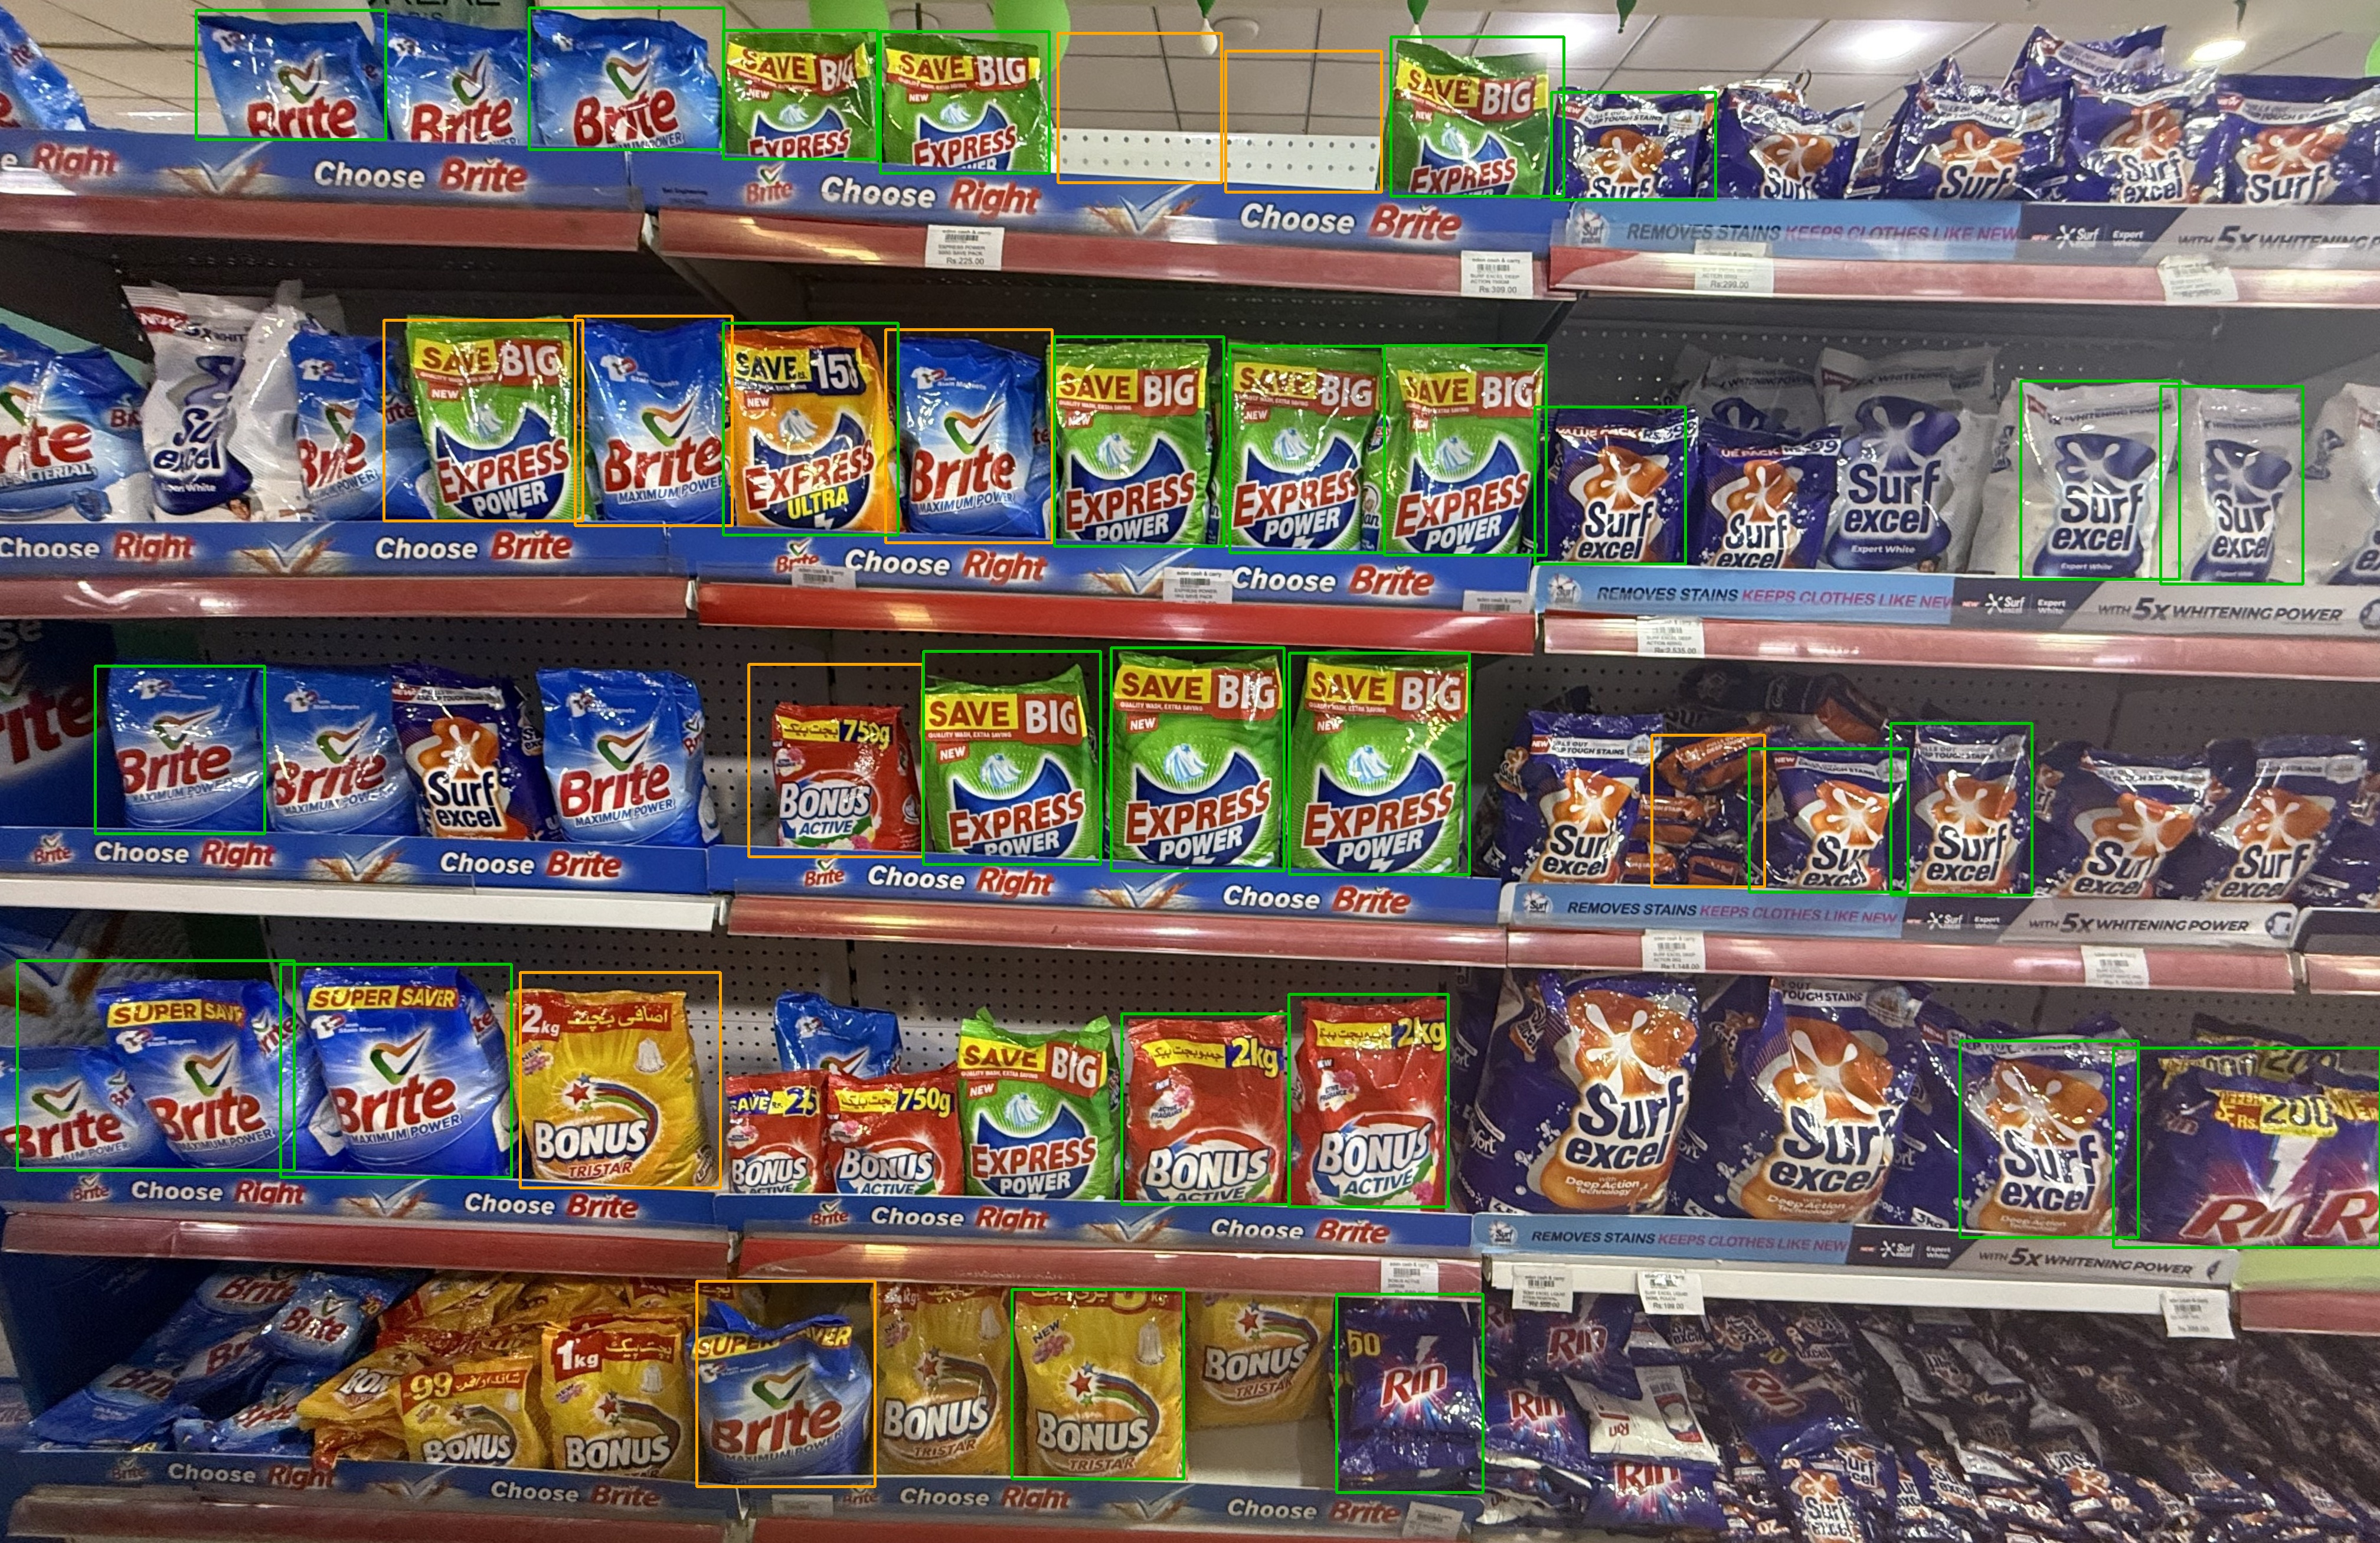

In [7]:
def draw_annotated_report(query_img_path, report, output_path="shelf_report_annotated.jpg"):
    img = cv2.imread(query_img_path)
    colors = {"missing": (0,0,255), "misplaced": (0,165,255), "compliant": (0,200,0)}
    thickness = {"missing": 3, "misplaced": 3, "compliant": 3}   # compliant ab 1 se 3 kar diya

    for status, boxes in report.items():
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), colors[status], thickness[status])

    cv2.imwrite(output_path, img)
    return output_path

output_path = draw_annotated_report(query_aligned_path, report)
display(Image(filename=output_path))